# LSTM Evaluation (HDFS)

### Импорты

In [11]:
import sys
import json

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "Checkpoint_5"))

from FastAPI.model.lstm_model import LSTMNextEventModel

from FastAPI.model.lstm_metrics import (
    block_confusion_from_ratio_map,
    predict_topk_miss,
    block_anomaly_ratio_map,
    sweep_thresholds,
)

### Загрузка данных

In [12]:
DATA_PATH = (
    ROOT
    / "Checkpoint_5"
    / "data"
    / "preprocessed"
    / "seq_out"
    / "hdfs_sequence_data.npz"
)
MODEL_PATH = ROOT / "Checkpoint_5" / "FastAPI" / "model" / "lstm_model.pt"
HISTORY_PATH = ROOT / "Checkpoint_5" / "experiments" / "lstm_model.history.json"
LOG_PATH = ROOT / "Checkpoint_5" / "data" / "HDFS.log"

In [13]:
data = np.load(DATA_PATH, allow_pickle=True)
x_train = data["X_train"]
y_train = data["y_train"]
x_val = data["X_val"]
y_val = data["y_val"]
x_test = data["X_test"]
y_test = data["y_test"]
val_labels = data["val_labels"]
val_block_ids = data["val_block_ids"]
test_labels = data["test_labels"]
test_block_ids = data["test_block_ids"]

print("Train size:", x_train.shape[0])
print("Val size:", x_val.shape[0])
print("Test size:", x_test.shape[0])

Train size: 4242856
Val size: 579655
Test size: 645520


### Загрузка модели

In [14]:
ckpt = torch.load(MODEL_PATH, map_location="cpu")
config = ckpt.get("config", {})
vocab_size = int(ckpt["vocab_size"])

model = LSTMNextEventModel(
    vocab_size=vocab_size,
    embedding_dim=int(config.get("embedding_dim", 32)),
    hidden_size=int(config.get("hidden_size", 64)),
    num_layers=int(config.get("num_layers", 1)),
    dropout=float(config.get("dropout", 0.0)),
)
model.load_state_dict(ckpt["state_dict"])

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

config

{'embedding_dim': 32,
 'hidden_size': 64,
 'num_layers': 1,
 'dropout': 0.0,
 'top_k': 3,
 'anomaly_ratio_threshold': 0.09183673469387756,
 'device': 'cpu'}

### Оценка качества

In [15]:
top_k = int(config.get("top_k", 3))
default_thr = float(config.get("anomaly_ratio_threshold", 0.5))

# Считаем промахи по окнам
val_miss = predict_topk_miss(model, x_val, y_val, device, top_k)
test_miss = predict_topk_miss(model, x_test, y_test, device, top_k)

# Агрегируем промахи по окнам (для каждого block_id получаем anomaly_ratio)
val_ratio_map = block_anomaly_ratio_map(val_miss, val_block_ids)
test_ratio_map = block_anomaly_ratio_map(test_miss, test_block_ids)

# Достаем значения anomaly_ratio
val_ratios = np.array(list(val_ratio_map.values()), dtype=float)
test_ratios = np.array(list(test_ratio_map.values()), dtype=float)

# Метки для валидации и теста
test_label_map = {str(bid): int(lbl) for bid, lbl in zip(test_block_ids, test_labels)}
val_label_map = {str(bid): int(lbl) for bid, lbl in zip(val_block_ids, val_labels)}

In [20]:
def print_confusion_metrics(tp, fp, tn, fn):
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    fpr = fp / (fp + tn)
    f1 = (2 * precision * recall / (precision + recall))

    print("Confusion matrix (test):")
    print(f" TP: {tp}  FP: {fp}")
    print(f" FN: {fn}  TN: {tn}")
    print()
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"FPR:       {fpr:.3f}")

tp, fp, tn, fn = block_confusion_from_ratio_map(test_ratio_map, test_label_map, default_thr)
print_confusion_metrics(tp, fp, tn, fn)

Confusion matrix (test):
 TP: 5536  FP: 1213
 FN: 1944  TN: 54610

Precision: 0.820
Recall:    0.740
F1:        0.778
FPR:       0.022


- Precision: 0.820 - большинство срабатываний действительно аномалии
- Recall: 0.740 - модель пропускает около 26% аномалий
- FPR: 0.022 - очень мало ложных тревог на норме
- F1: 0.778 - среднее качество с упором на точность


### Распределение anomaly_ratio по блокам

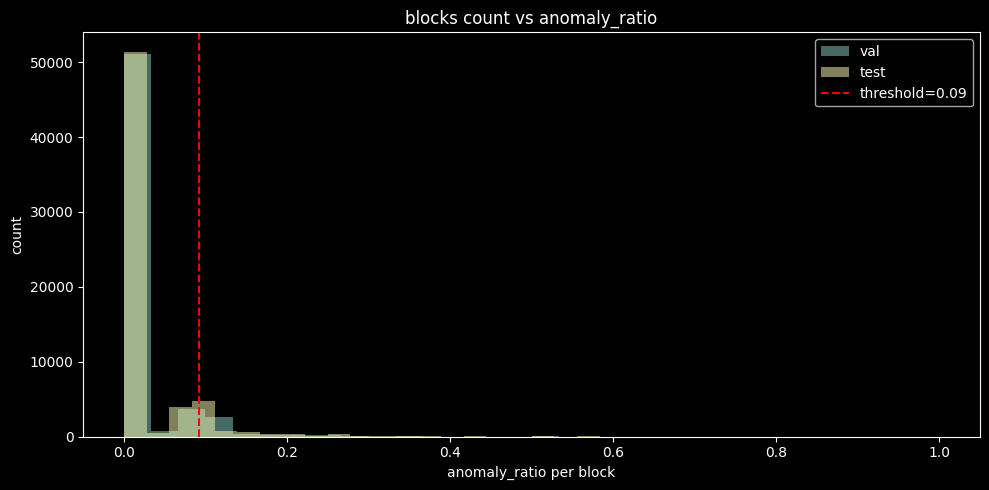

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(val_ratios, bins=30, alpha=0.5, label="val")
plt.hist(test_ratios, bins=30, alpha=0.5, label="test")
plt.axvline(default_thr, color="red", linestyle="--", label=f"threshold={default_thr:.2f}")
plt.title("blocks count vs anomaly_ratio")
plt.xlabel("anomaly_ratio per block")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

- Распределения val и test близки - подбор порога по val даст хороший результатна test
- Почти все anomaly_ratio около 0 - модель хорошо предсказывает next-event для большинства блоков
- Разделимость не идеальная - есть перекрытие val и test около 0.1, это объясняет FP и FN

### Зависимость FPR от порога на валидации

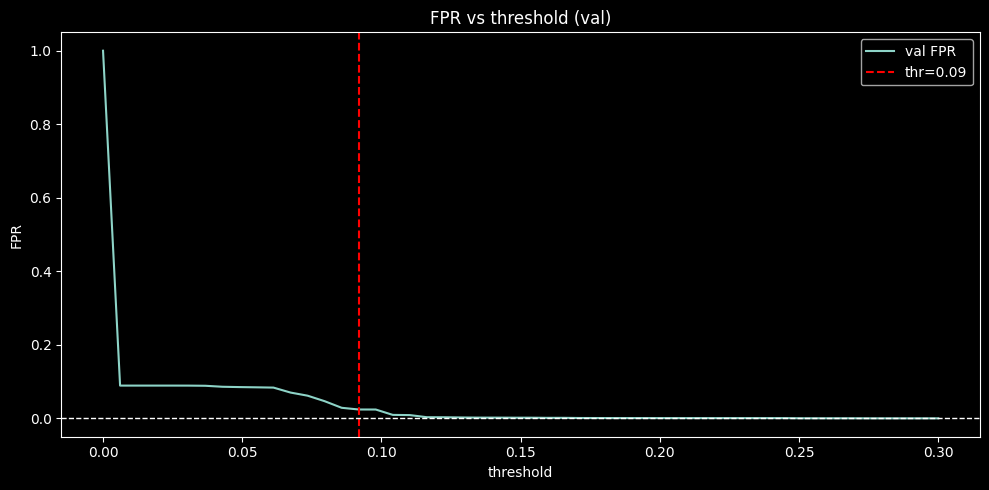

In [18]:
thresholds = np.linspace(0.0, 0.3, 50)
val_fpr = []
for t in thresholds:
    tp, fp, tn, fn = block_confusion_from_ratio_map(val_ratio_map, val_label_map, t)
    val_fpr.append(fp / (fp + tn) if (fp + tn) else 0.0)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, val_fpr, label="val FPR")
plt.axvline(default_thr, color="red", linestyle="--", label=f"thr={default_thr:.2f}")
plt.axhline(0, color="white", linestyle="--", linewidth=1)
plt.title("FPR vs threshold (val)")
plt.xlabel("threshold")
plt.ylabel("FPR")
plt.legend()
plt.tight_layout()
plt.show()

- FPR резко падает при малых порогах - даже небольшой порог (около 0.01) сильно снижает ложные срабатывания на норме
- threshold=0.09 - порог почти не допускает ложных срабатываний на норме (около 2% ложных срабатываний)

### Зависимость Precision/Recall/F1 от порога на тесте

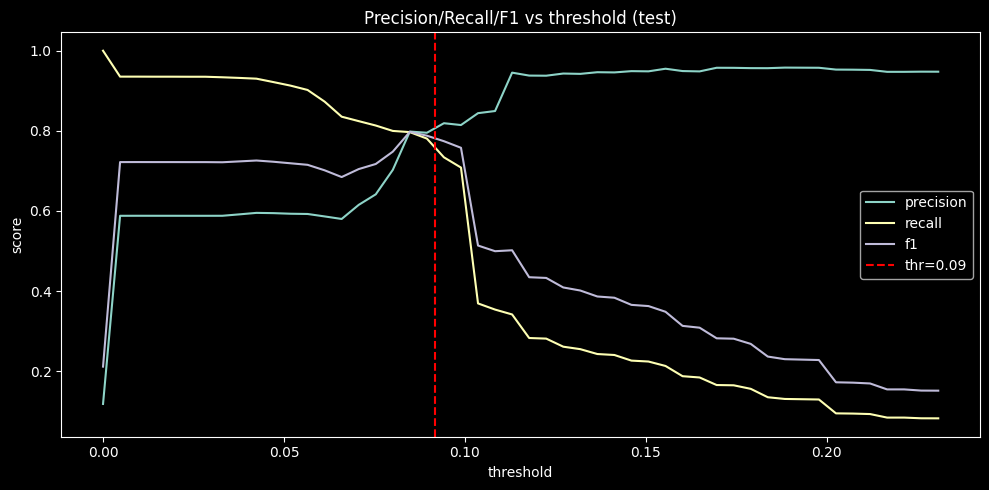

Best threshold: 0.0848
Best F1: 0.7975


In [19]:
max_thr = float(np.quantile(test_ratios, 0.99)) if test_ratios.size else 0.5
thresholds = np.linspace(0.0, max(0.2, max_thr), 50)

sweep = sweep_thresholds(test_ratio_map, test_label_map, thresholds)
thr_vals = np.array([row[0] for row in sweep])
prec_vals = np.array([row[1] for row in sweep])
rec_vals = np.array([row[2] for row in sweep])
f1_vals = np.array([row[3] for row in sweep])

plt.figure(figsize=(10, 5))
plt.plot(thr_vals, prec_vals, label="precision")
plt.plot(thr_vals, rec_vals, label="recall")
plt.plot(thr_vals, f1_vals, label="f1")
plt.axvline(default_thr, color="red", linestyle="--", label=f"thr={default_thr:.2f}")
plt.title("Precision/Recall/F1 vs threshold (test)")
plt.xlabel("threshold")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(f1_vals))
print("Best threshold:", round(thresholds[best_idx], 4))
print("Best F1:", round(f1_vals[best_idx], 4))

- Лучший по F1 порог на тесте threshold=0.085, при нем значение F1=0.778
- Текущий порог, подобранный на валидации (threshold=0.09) оказался близок к лучшему по тесту